In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/AEP_hourly.csv")
print(df.shape)
print(df.head())
print(df.columns)
print(df.dtypes)



(121273, 2)
              Datetime   AEP_MW
0  2004-12-31 01:00:00  13478.0
1  2004-12-31 02:00:00  12865.0
2  2004-12-31 03:00:00  12577.0
3  2004-12-31 04:00:00  12517.0
4  2004-12-31 05:00:00  12670.0
Index(['Datetime', 'AEP_MW'], dtype='object')
Datetime     object
AEP_MW      float64
dtype: object


In [11]:
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values("Datetime").reset_index(drop=True)
print(df.head( ))
print(df.dtypes)
print(f"Date range: {df['Datetime'].min()} to {df['Datetime'].max()}")


             Datetime   AEP_MW
0 2004-10-01 01:00:00  12379.0
1 2004-10-01 02:00:00  11935.0
2 2004-10-01 03:00:00  11692.0
3 2004-10-01 04:00:00  11597.0
4 2004-10-01 05:00:00  11681.0
Datetime    datetime64[ns]
AEP_MW             float64
dtype: object
Date range: 2004-10-01 01:00:00 to 2018-08-03 00:00:00


In [12]:
print(df.isnull().sum())
print(f"Total readings: {len(df)}")

Datetime    0
AEP_MW      0
dtype: int64
Total readings: 121273


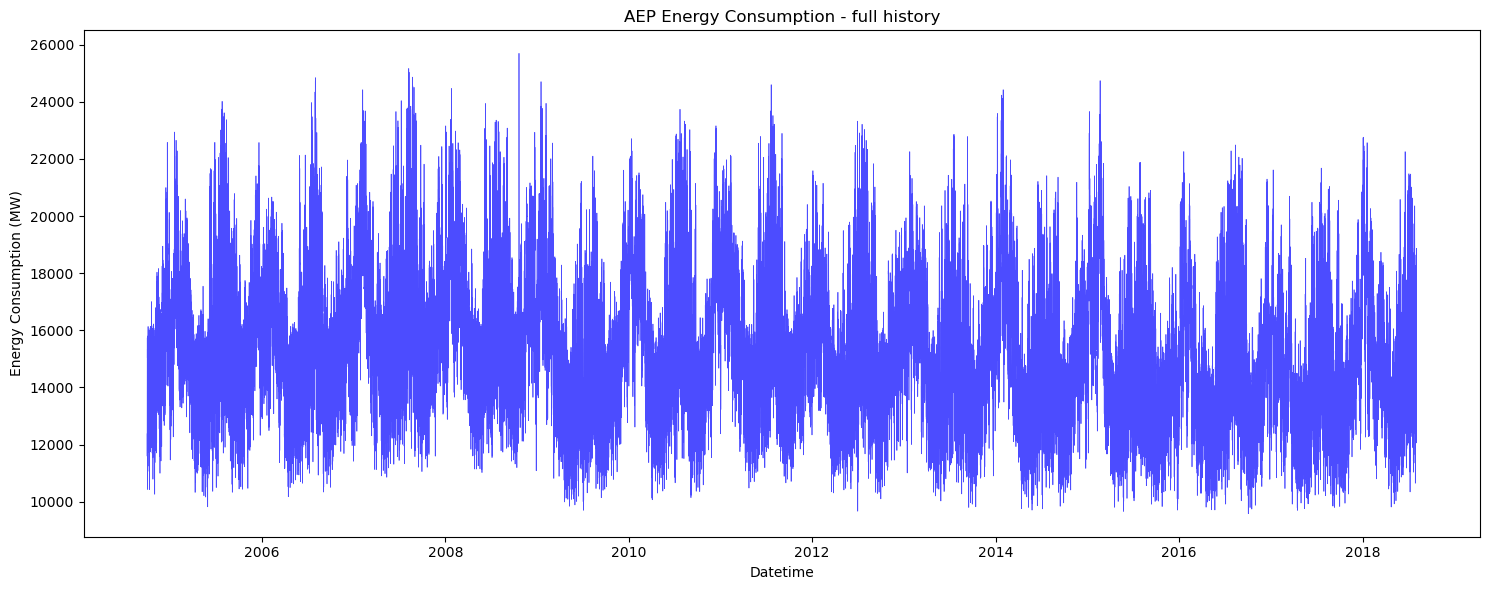

In [13]:
plt.figure(figsize=(15, 6))
plt.plot(df['Datetime'], df['AEP_MW'], color='blue', linewidth=0.5, alpha=0.7)
plt.title('AEP Energy Consumption - full history')
plt.xlabel('Datetime')
plt.ylabel('Energy Consumption (MW)')
plt.tight_layout()
plt.savefig('energy_consumption_full_history.png')
plt.show()


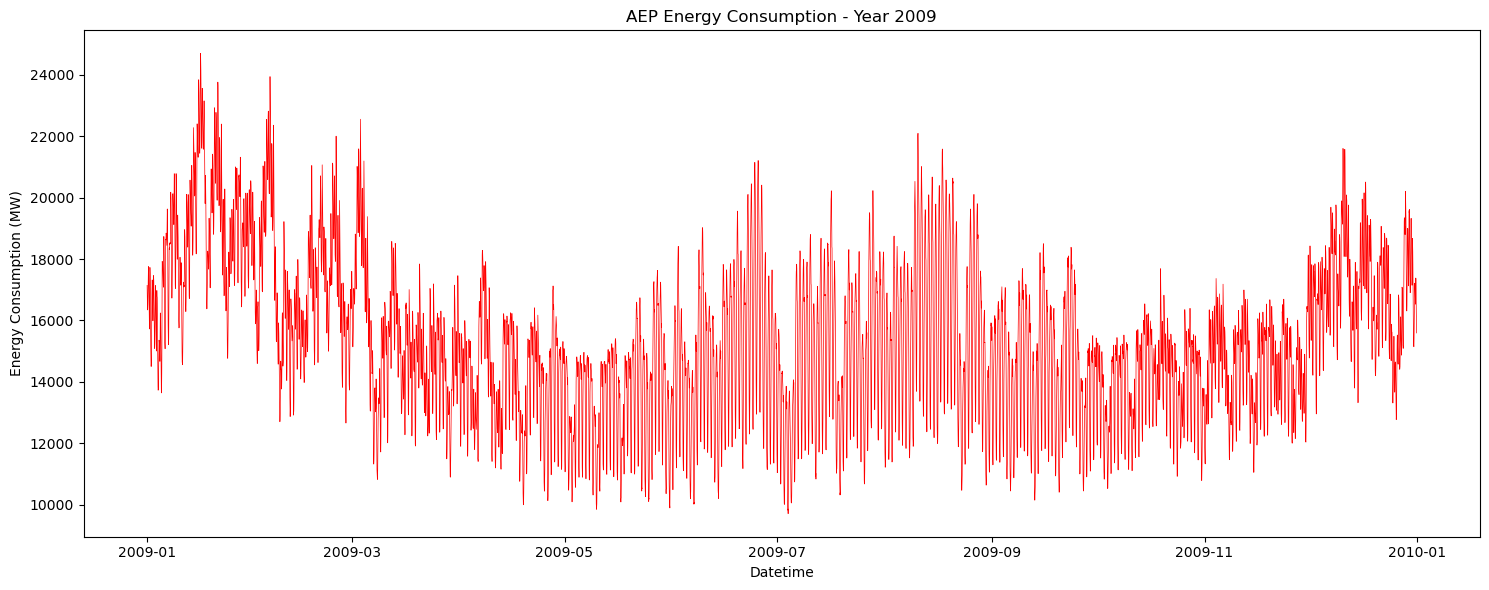

In [14]:
year_data = df[df['Datetime'].dt.year == 2009]
plt.figure(figsize=(15, 6))
plt.plot(year_data['Datetime'], year_data['AEP_MW'], color='red', linewidth=0.5)
plt.title('AEP Energy Consumption - Year 2009')
plt.xlabel('Datetime')
plt.ylabel('Energy Consumption (MW)')
plt.tight_layout()
plt.savefig('energy_consumption_2009.png')
plt.show()

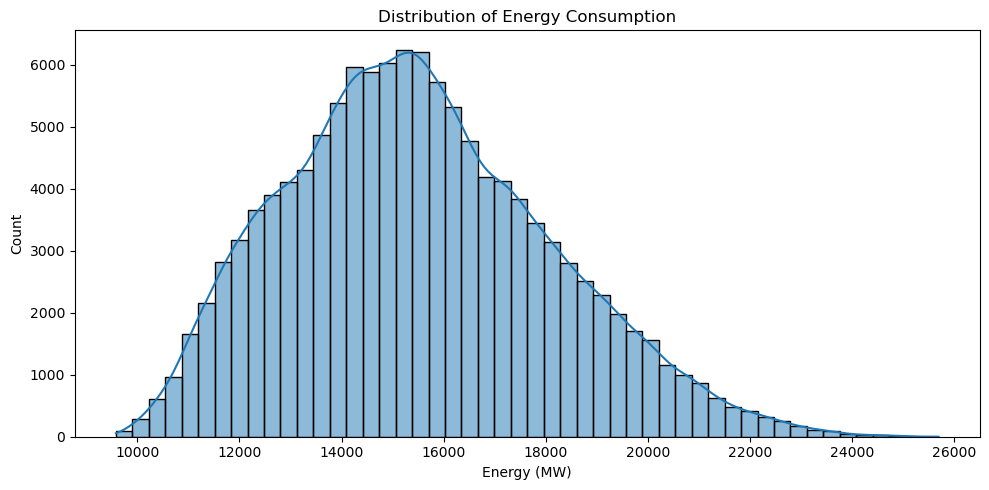

Mean: 15500 MW
Std: 2591 MW
Min: 9581 MW
Max: 25695 MW


In [15]:
plt.figure(figsize=(10, 5))
sns.histplot(df["AEP_MW"], bins=50, kde=True)
plt.title("Distribution of Energy Consumption")
plt.xlabel("Energy (MW)")
plt.tight_layout()
plt.savefig("distribution.png")
plt.show()

print(f"Mean: {df['AEP_MW'].mean():.0f} MW")
print(f"Std: {df['AEP_MW'].std():.0f} MW")
print(f"Min: {df['AEP_MW'].min():.0f} MW")
print(f"Max: {df['AEP_MW'].max():.0f} MW")

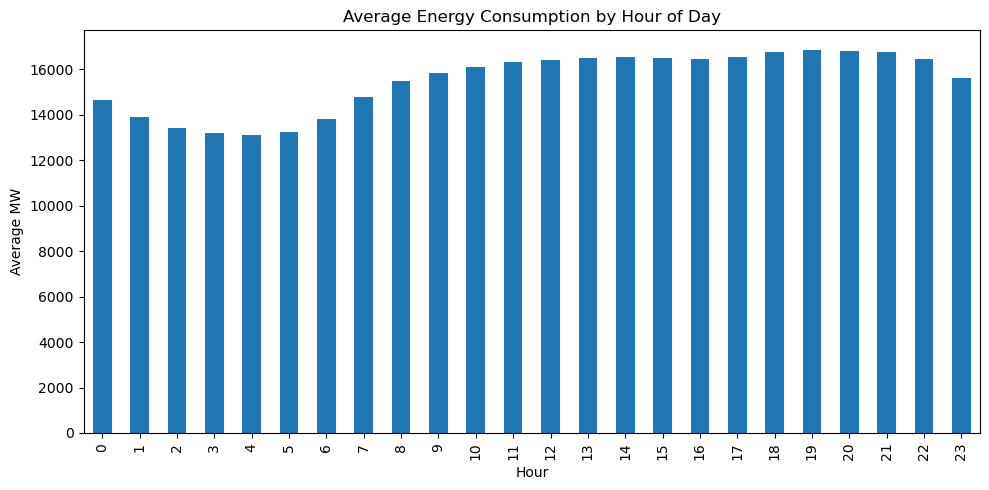

In [16]:
df["hour"] = df["Datetime"].dt.hour
hourly_avg = df.groupby("hour")["AEP_MW"].mean()

plt.figure(figsize=(10, 5))
hourly_avg.plot(kind="bar")
plt.title("Average Energy Consumption by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average MW")
plt.tight_layout()
plt.savefig("hourly_pattern.png")
plt.show()

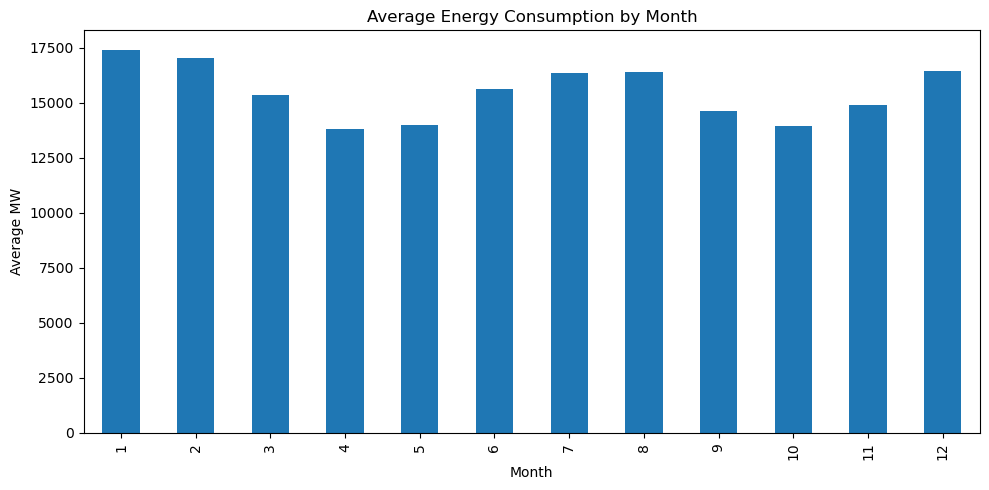

In [17]:
df["month"] = df["Datetime"].dt.month
monthly_avg = df.groupby("month")["AEP_MW"].mean()

plt.figure(figsize=(10, 5))
monthly_avg.plot(kind="bar")
plt.title("Average Energy Consumption by Month")
plt.xlabel("Month")
plt.ylabel("Average MW")
plt.tight_layout()
plt.savefig("monthly_pattern.png")
plt.show()

In [18]:
# Observation 1: In 2009 there was a significant energy consumption high in january and february, and a low in july and august. This is likely due to the cold weather in the winter months and the hot weather in the summer months, which leads to increased energy consumption for heating and cooling.
# Observation 2: Theres a significant spike in energy consumption daily by 6am maybe because thats when people wake up and start using energy for cooking, heating, and other activities. There is also a smaller spike in the evening around 6pm when people return home from work and use energy for lighting, cooking, and entertainment.
# Observation 3: From 12pm to 5pm it looks like energy consumption is relatively the same, which is likely due to the fact that people are at work or school during these hours and are not using as much energy at home.
# Observation 4: energy is actually HIGH in both winter AND summer (heating and cooling) and LOWER in spring and autumn. That's a U-shaped pattern, not a simple winter/summer split.
# Observation 5: From the distribution plot, we can see that the majority of energy consumption readings are between 5000 MW and 10000 MW, with a few outliers above 15000 MW. This indicates that while there are some extreme values, most of the data falls within a relatively narrow range.